Loading the proper libraries and packages into the notebook. NOTE: An entire neural network is 100% overkill for this application. Simple machine learing would be more that sufficient but the NN is used for exposure and not practicality.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import tensorflow_hub as hub
from imblearn.over_sampling import RandomOverSampler

Importing the CSV file to be used in this simple demonstration of Tensorflow.

In [ ]:
df = pd.read_csv('diabetes.csv')
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


Basic histograms of the data compared to the outcome (1 for diabetes diagnosis and 0 for no diabetes diagnosis)

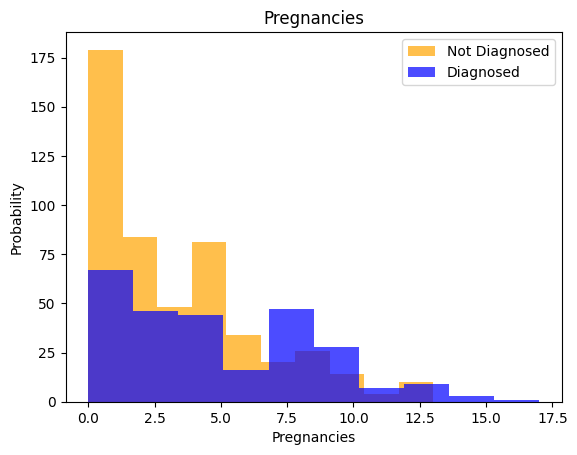

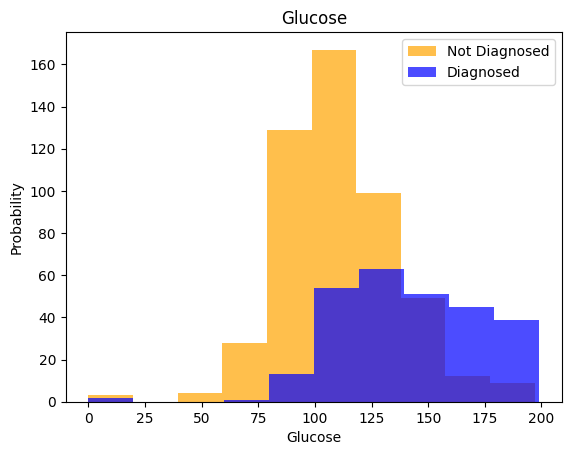

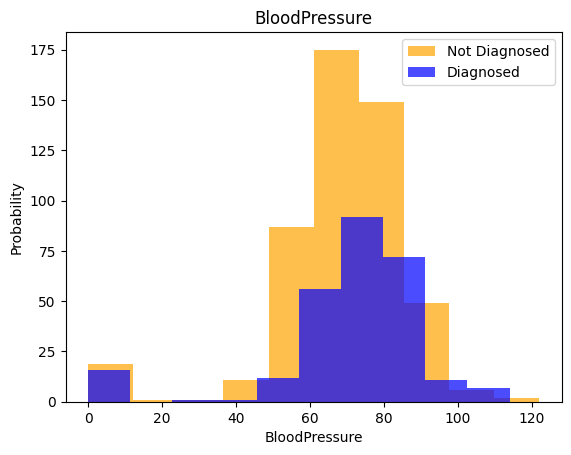

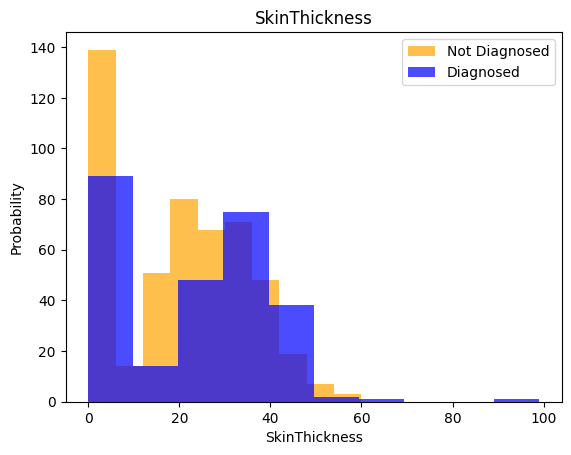

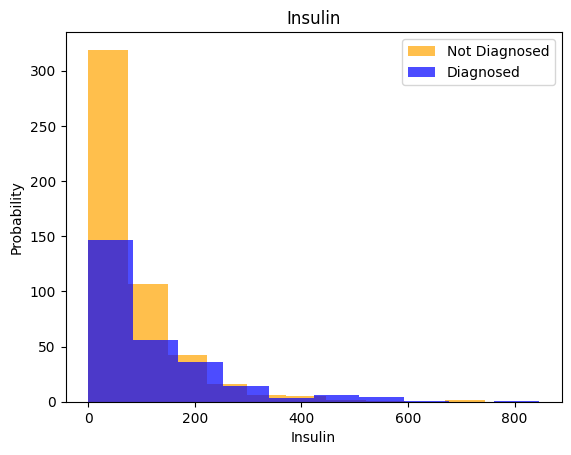

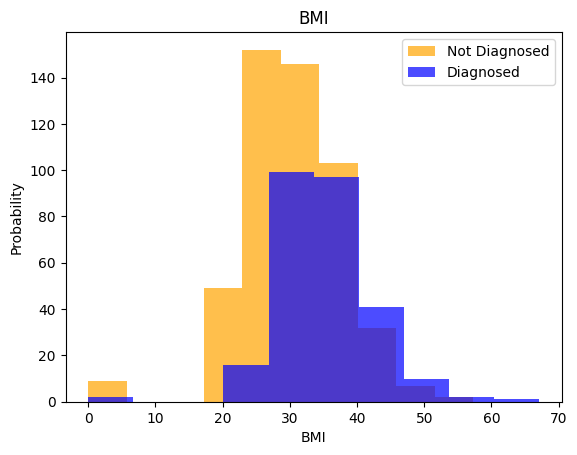

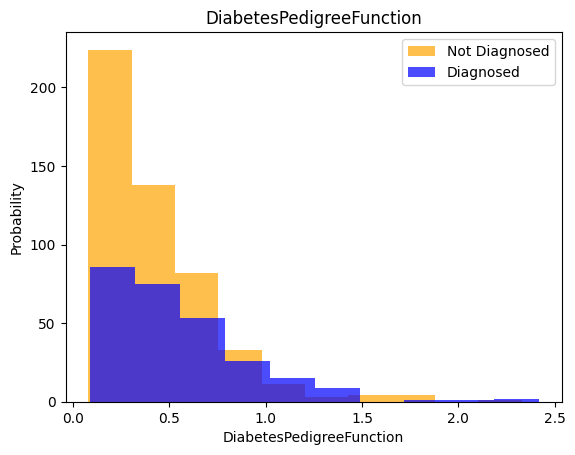

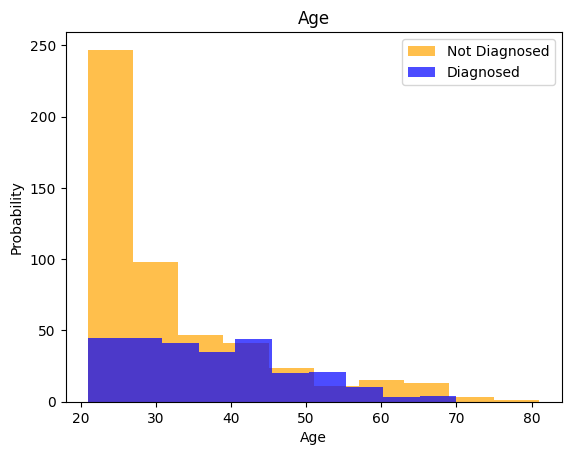

In [ ]:
for name in df.columns[:-1]:
  lable = name
  plt.hist(df[df['Outcome']==0][name], color='orange', label='Not Diagnosed',
           alpha=0.7)
  plt.hist(df[df['Outcome']==1][name], color = 'blue', label='Diagnosed',
           alpha=0.7)
  plt.legend()
  plt.xlabel(lable)
  plt.ylabel('Probability')
  plt.title(lable)
  plt.show()

It is also required to normalize the histograms in order to see the real relation between the variables.

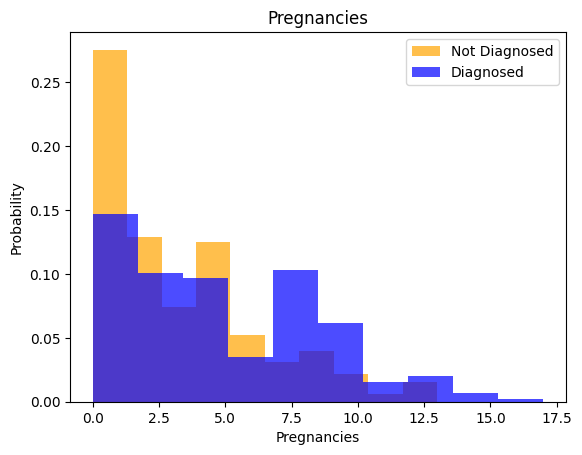

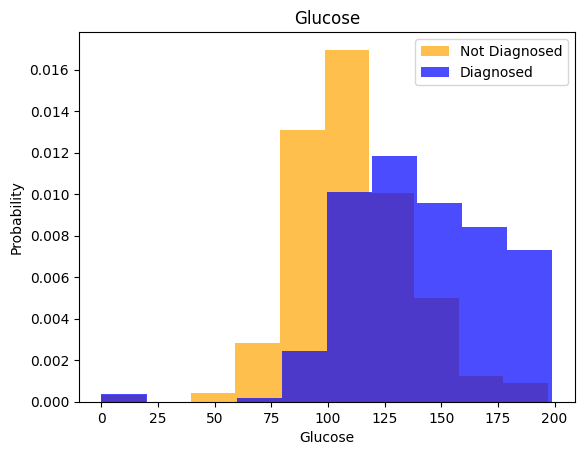

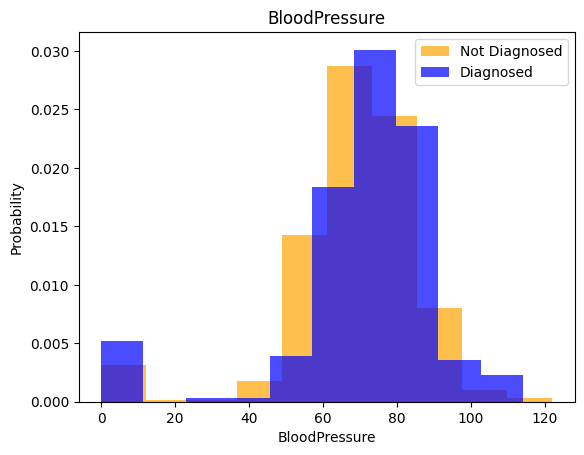

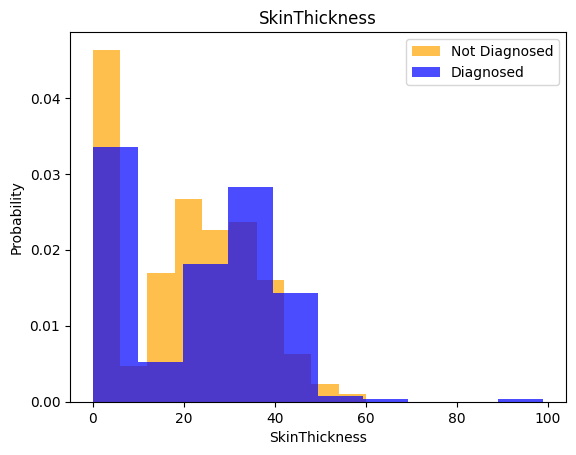

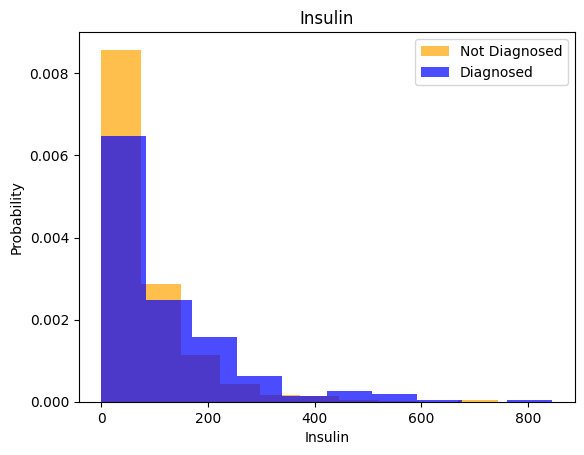

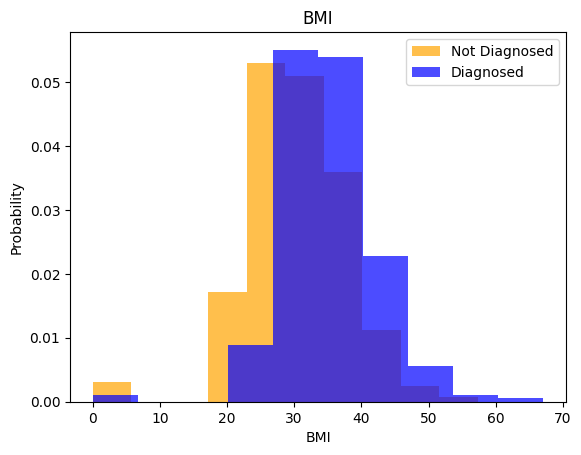

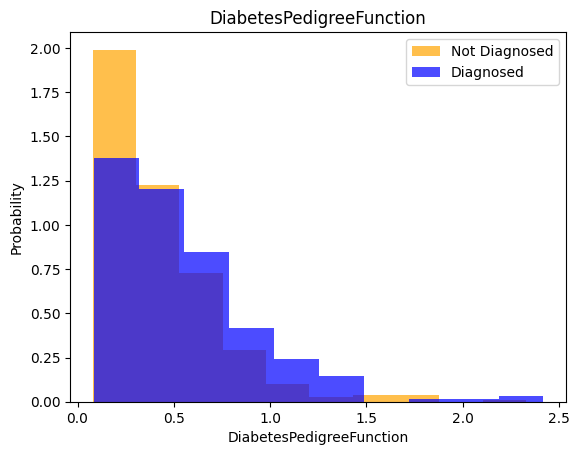

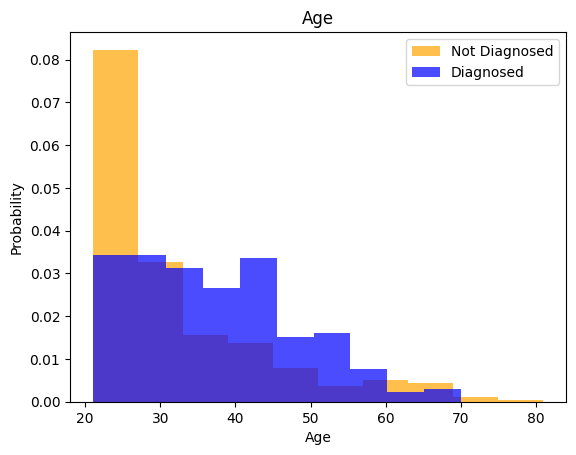

In [ ]:
for name in df.columns[:-1]:
  lable = name
  plt.hist(df[df['Outcome']==0][name], color='orange', label='Not Diagnosed',
           alpha=0.7, density=True)
  plt.hist(df[df['Outcome']==1][name], color = 'blue', label='Diagnosed',
           alpha=0.7, density=True)
  plt.legend()
  plt.xlabel(lable)
  plt.ylabel('Probability')
  plt.title(lable)
  plt.show()

next, we must define the X and Y variables in order to be able to properly

In [ ]:
x = df[df.columns[:-1]].values#creates a matrix of values which holds all of
                              #the values of every column aside from name.
y = df[df.columns[-1]].values#creates an array of values that house only the
                             #values from the last column.

print(x)
print(y)

[[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]
[1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0

Uses the standard scaler package in order to scale the data based on a mean and standard deviation from said mean. Essentially, horizontal normalization of the data.

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)
print(x)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


making the lengths of the inputs and outputs match up much more.

In [ ]:
over = RandomOverSampler()
x, y = over.fit_resample(x, y)
print(len(x), len(y))

1000 1000


Now it is possible to split the data into the training and testing portions

In [ ]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=0) #dedicate 40% of the data to the temporary set and the rest to training the model
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=0) #dedicate half of that 40% to the testing of the training and the other half to find tuning the model.

Finally building the neural network using TensorFlow.

In [ ]:
#Allows for the TensorFlow neurons to be put into a sequence able to perform a
#given task.
model = tf.keras.Sequential([
    #The layer of said neurons that take in a value and output a value (dense).
    #A layer where every neuron of it is reciveing input from every neuron of
    #the pervous layer.
    #Code has 16 neurons.
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    #Output layer that maps the probability of an input having or not having
    #diabetes (0 0r 1).
    tf.keras.layers.Dense(1, activation='sigmoid')
])

The optimizer adjusts the weights and biases of the functions to minimize the loss function.
The loss gives the sorts of values that the model is going to seek to minimize.
The metrics is what the model seeks to base the optimizatoin off of.

In essense the compile function is what tells the network how to perform in a positive manner and how to optimize it to what we need most.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

Testing the raw accuracy of the NN based on the supplied data with zero training.

In [ ]:
model.evaluate(x_train, y_train)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4685 - loss: 0.8254  


[0.8123146891593933, 0.4650000035762787]

In [ ]:
model.evaluate(x_valid, y_valid)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5464 - loss: 0.7569 


[0.7696402668952942, 0.5049999952316284]

Training the NN on the supplied data.
The batch size is the number of examples used in one "forward pass" and "backward pass" here, 16.
The Epochs is the number of times it will perform the passes, here 20.
The validation is what the model will compare itself to in order to test the accuracy.

In [ ]:
model.fit(x_train, y_train, batch_size=16, epochs=20, validation_data=(x_valid, y_valid))

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4973 - loss: 0.7823 - val_accuracy: 0.6400 - val_loss: 0.6541
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6517 - loss: 0.6463 - val_accuracy: 0.6800 - val_loss: 0.5973
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6600 - loss: 0.5972 - val_accuracy: 0.7250 - val_loss: 0.5602
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7039 - loss: 0.5916 - val_accuracy: 0.7450 - val_loss: 0.5332
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7492 - loss: 0.5336 - val_accuracy: 0.7500 - val_loss: 0.5125
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7565 - loss: 0.5221 - val_accuracy: 0.7700 - val_loss: 0.5007
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7641 - loss: 0.5147 - val_accuracy: 0.7650 - val_loss: 0.4918
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7428 - loss: 0.5171 - val_accuracy: 0.7700 - val_loss:

Perform an evaluation now that the model has been trained.

In [ ]:
model.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8411 - loss: 0.4078 


[0.436456561088562, 0.824999988079071]

Clearly the model has been trained well, achieiving ~84% accuracy after training on the relatively small dataset.